## Portfolio Optimization using Python
This project analyzes multiple stocks and constructs optimal portfolios 
based on risk and return trade-offs.

In [47]:
!pip install yfinance pandas


In [48]:
import yfinance as yf
import pandas as pd

### Step 1: Data Collection

We fetch historical stock data for selected companies using yfinance.

---> We start with Reliance

In [49]:
data = yf.download("RELIANCE.NS", start="2020-01-01", end="2024-01-01", auto_adjust = False)
data

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,,
2020-01-01,675.324280,690.138306,698.138733,688.263977,693.978516,14004468
2020-01-02,686.821289,701.887512,704.470520,691.235535,691.235535,17710316
2020-01-03,687.648865,702.733276,704.790527,696.264343,700.835999,20984698
2020-01-06,671.700745,686.435303,698.504456,684.835205,694.892883,24519177
2020-01-07,682.034546,696.995850,701.521790,691.921265,694.435669,16683622
...,...,...,...,...,...,...
2023-12-22,1273.102173,1282.525024,1290.449951,1273.824951,1279.800049,16541784
2023-12-26,1279.554443,1289.025024,1295.974976,1281.349976,1284.000000,7465664


In [50]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,,
2020-01-01,675.324280,690.138306,698.138733,688.263977,693.978516,14004468
2020-01-02,686.821289,701.887512,704.470520,691.235535,691.235535,17710316
2020-01-03,687.648865,702.733276,704.790527,696.264343,700.835999,20984698
2020-01-06,671.700745,686.435303,698.504456,684.835205,694.892883,24519177
2020-01-07,682.034546,696.995850,701.521790,691.921265,694.435669,16683622


In [51]:
data.to_csv("reliance.csv")

In [52]:
data.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,,
2023-12-22,1273.102173,1282.525024,1290.449951,1273.824951,1279.800049,16541784
2023-12-26,1279.554443,1289.025024,1295.974976,1281.349976,1284.000000,7465664
2023-12-27,1283.922119,1293.425049,1299.949951,1286.550049,1291.000000,9204156
2023-12-28,1293.203369,1302.775024,1306.000000,1293.425049,1294.900024,12302636
2023-12-29,1282.979126,1292.474976,1307.000000,1289.650024,1305.550049,10864584


In [53]:
print(data.columns)

MultiIndex([('Adj Close', 'RELIANCE.NS'),
            (    'Close', 'RELIANCE.NS'),
            (     'High', 'RELIANCE.NS'),
            (      'Low', 'RELIANCE.NS'),
            (     'Open', 'RELIANCE.NS'),
            (   'Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


In [54]:
data.loc["2023-12-29"]


Price      Ticker     
Adj Close  RELIANCE.NS    1.282979e+03
Close      RELIANCE.NS    1.292475e+03
High       RELIANCE.NS    1.307000e+03
Low        RELIANCE.NS    1.289650e+03
Open       RELIANCE.NS    1.305550e+03
Volume     RELIANCE.NS    1.086458e+07
Name: 2023-12-29 00:00:00, dtype: float64

In [55]:
data.columns = data.columns.droplevel(1)

In [56]:
data.loc["2023-12-29"]



Price
Adj Close    1.282979e+03
Close        1.292475e+03
High         1.307000e+03
Low          1.289650e+03
Open         1.305550e+03
Volume       1.086458e+07
Name: 2023-12-29 00:00:00, dtype: float64

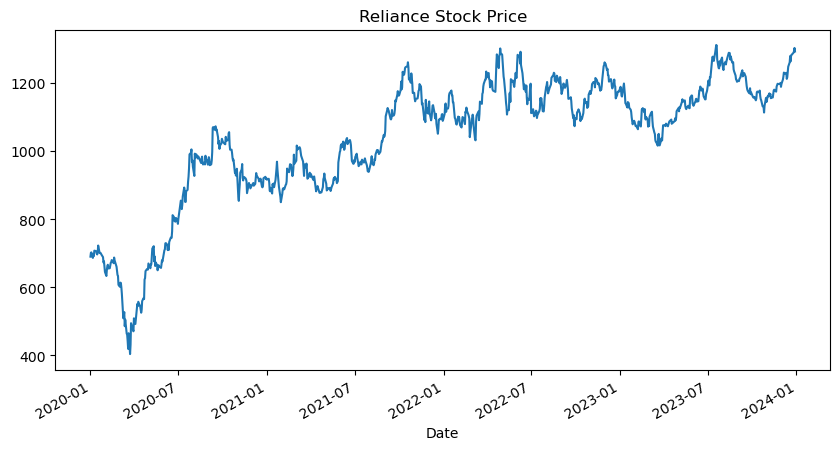

In [57]:
import matplotlib.pyplot as plt

data["Close"].plot(figsize=(10,5))
plt.title("Reliance Stock Price")
plt.show()

In [58]:
data.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2023-12-22,1273.102173,1282.525024,1290.449951,1273.824951,1279.800049,16541784
2023-12-26,1279.554443,1289.025024,1295.974976,1281.349976,1284.000000,7465664
2023-12-27,1283.922119,1293.425049,1299.949951,1286.550049,1291.000000,9204156
2023-12-28,1293.203369,1302.775024,1306.000000,1293.425049,1294.900024,12302636
2023-12-29,1282.979126,1292.474976,1307.000000,1289.650024,1305.550049,10864584


In [59]:
data2=yf.download("RELIANCE.NS")

[*********************100%***********************]  1 of 1 completed


In [60]:
data2.columns.droplevel(1)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [61]:
data2

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-02-20,1419.400024,1427.400024,1406.099976,1409.500000,8177670
2026-02-23,1428.000000,1434.900024,1418.300049,1425.000000,7758856
2026-02-24,1428.800049,1433.300049,1415.000000,1425.300049,12529409
2026-02-25,1398.500000,1440.500000,1393.500000,1435.000000,10728792
2026-02-26,1406.800049,1412.900024,1391.900024,1398.500000,16683858
2026-02-27,1393.900024,1410.400024,1388.099976,1398.000000,12031440
2026-03-02,1358.000000,1378.599976,1341.500000,1375.500000,23728722
2026-03-04,1345.000000,1352.800049,1307.000000,1330.000000,32495007


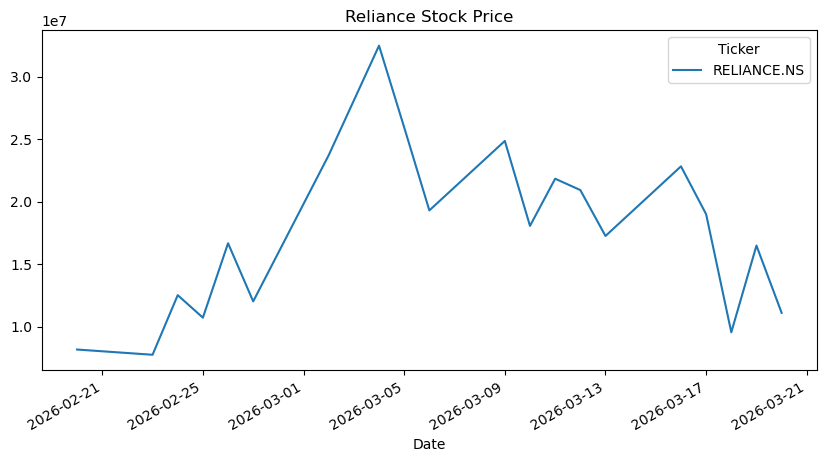

In [62]:
import matplotlib.pyplot as plt

data2["Volume"].plot(figsize=(10,5))
plt.title("Reliance Stock Price")
plt.show()

In [63]:
returns = data["Close"].pct_change()
returns

Date
2020-01-01         NaN
2020-01-02    0.017024
2020-01-03    0.001205
2020-01-06   -0.023192
2020-01-07    0.015385
                ...   
2023-12-22    0.000976
2023-12-26    0.005068
2023-12-27    0.003413
2023-12-28    0.007229
2023-12-29   -0.007906
Name: Close, Length: 992, dtype: float64

In [64]:
returns.head()

Date
2020-01-01         NaN
2020-01-02    0.017024
2020-01-03    0.001205
2020-01-06   -0.023192
2020-01-07    0.015385
Name: Close, dtype: float64

<Axes: xlabel='Date'>

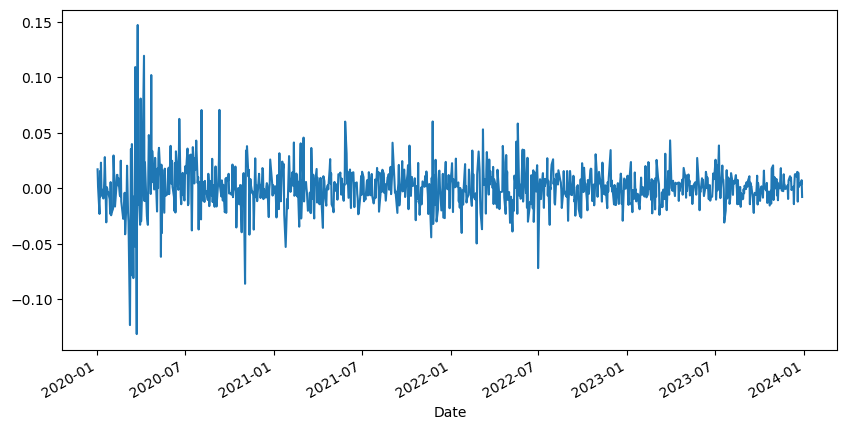

In [65]:
returns.plot(figsize=(10,5))

In [66]:
returns=returns.dropna()

<Axes: xlabel='Date'>

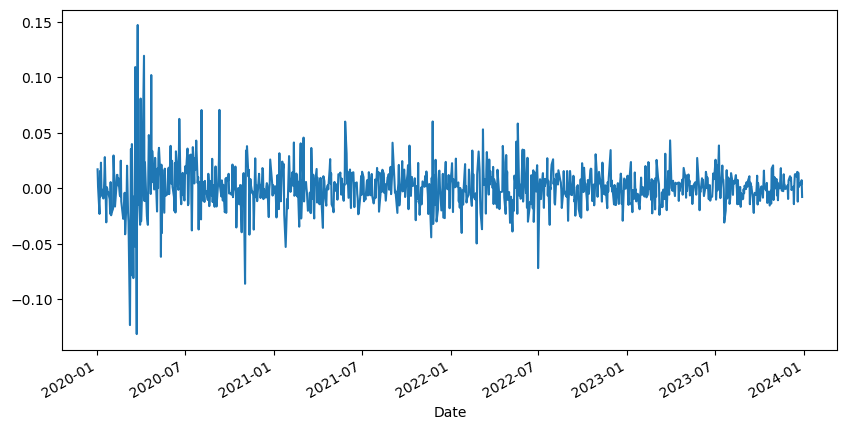

In [67]:
returns.plot(figsize = (10,5))

# ---> Here we take data of infosys, tcs and reliance

In [68]:
stocks = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]
data = yf.download(stocks, start = "2020-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  3 of 3 completed


Price            Close                                 High              \
Ticker         INFY.NS RELIANCE.NS       TCS.NS     INFY.NS RELIANCE.NS   
Date                                                                      
2020-01-01  633.151184  675.324280  1866.113892  635.857897  683.152975   
2020-01-02  631.303772  686.821289  1857.547729  636.545282  689.348852   
2020-01-03  641.013428  687.648865  1894.566772  642.731962  689.661956   
2020-01-06  634.869629  671.700745  1894.394287  647.715686  683.510829   
2020-01-07  625.460815  682.034546  1899.043091  638.092005  686.463335   

Price                           Low                                 Open  \
Ticker           TCS.NS     INFY.NS RELIANCE.NS       TCS.NS     INFY.NS   
Date                                                                       
2020-01-01  1880.146596  629.456345  673.490184  1854.405398  631.561560   
2020-01-02  1876.746120  628.038566  676.397959  1850.273061  634.912706   
2020-01-03  1913.808249  630.616314  681.318790  1863.014417  630.616314   
2020-01-06  1916.347549  632.850372  670.134994  1883.589797  641.099317   
2020-01-07  1906.618949  623.054825  677.068889  1880.059936  634.139396   

Price                                 Volume                       
Ticker     RELIANCE.NS       TCS.NS  INFY.NS RELIANCE.NS   TCS.NS  
Date                                                               
2020-01-01  679.082058  1866.458173  2112415    14004468  1354908  
2020-01-02  676.397959  1876.746120  5658200    17710316  2380752  
2020-01-03  685.792313  1863.014417  7882938    20984698  4655761  
2020-01-06  679.976780  1898.311480  6519403    24519177  3023209  
2020-01-07  679.529321  1894.437127  7899363    16683622  2429317

## Step 2: Data Cleaning & Preparation

We extract closing prices and prepare the dataset for analysis.

In [69]:
close_prices = data["Close"]
close_prices.head()

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,633.151184,675.324280,1866.113892
2020-01-02,631.303772,686.821289,1857.547729
2020-01-03,641.013428,687.648865,1894.566772
2020-01-06,634.869629,671.700745,1894.394287
2020-01-07,625.460815,682.034546,1899.043091


## Step 3: Return Calculation

We compute daily returns to measure percentage change in stock prices.

In [70]:
returns = close_prices.pct_change()
returns.head()

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2020-01-01,NaN,NaN,NaN
2020-01-02,-0.002918,0.017024,-0.004590
2020-01-03,0.015380,0.001205,0.019929
2020-01-06,-0.009585,-0.023192,-0.000091
2020-01-07,-0.014820,0.015385,0.002454


<Axes: xlabel='Date'>

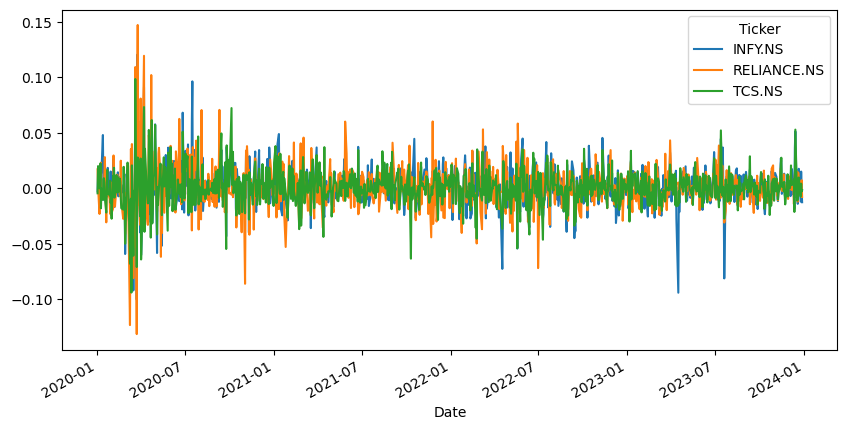

In [71]:
returns.plot(figsize = (10,5))

<Axes: xlabel='Date'>

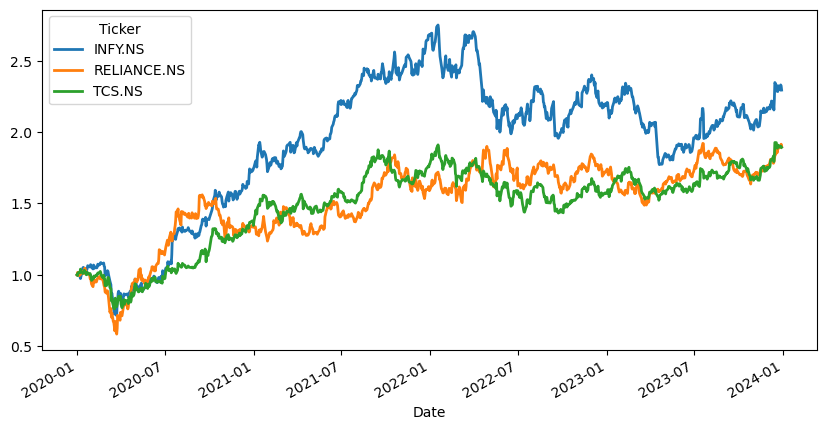

In [72]:
normalized = close_prices/close_prices.iloc[0]
normalized.plot(figsize=(10,5), linewidth=2)

In [73]:
print(close_prices.head())
print(close_prices.columns)

Ticker         INFY.NS  RELIANCE.NS       TCS.NS
Date                                            
2020-01-01  633.151184   675.324280  1866.113892
2020-01-02  631.303772   686.821289  1857.547729
2020-01-03  641.013428   687.648865  1894.566772
2020-01-06  634.869629   671.700745  1894.394287
2020-01-07  625.460815   682.034546  1899.043091
Index(['INFY.NS', 'RELIANCE.NS', 'TCS.NS'], dtype='object', name='Ticker')


In [74]:
normalized.tail()

Ticker,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,
2023-12-22,2.324005,1.885172,1.908446
2023-12-26,2.295827,1.894726,1.894247
2023-12-27,2.330251,1.901193,1.902058
2023-12-28,2.323634,1.914937,1.896418
2023-12-29,2.294266,1.899797,1.893174


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

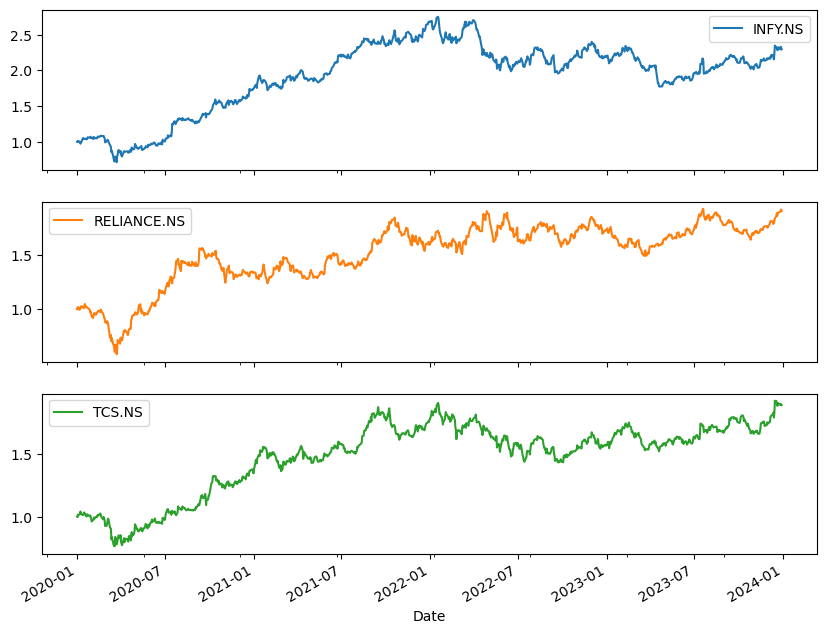

In [75]:
normalized.plot(subplots=True, figsize=(10,8))

In [76]:
print(normalized.shape)

(992, 3)


## Step 4: Risk Measurement

We calculate volatility (standard deviation) to quantify risk.

In [77]:
volatility = returns. std()
volatility

Ticker
INFY.NS        0.018249
RELIANCE.NS    0.019653
TCS.NS         0.015897
dtype: float64

In [78]:
returns = close_prices.pct_change().dropna()
volatility = returns.std()
print(volatility)


Ticker
INFY.NS        0.018249
RELIANCE.NS    0.019653
TCS.NS         0.015897
dtype: float64


In [79]:
avg_returns = returns.mean()
print(avg_returns)

Ticker
INFY.NS        0.001005
RELIANCE.NS    0.000840
TCS.NS         0.000771
dtype: float64


In [80]:
import pandas as pd
summary = pd.DataFrame({
    "Return": avg_returns,
    "Risk": volatility
})

print(summary)

               Return      Risk
Ticker                         
INFY.NS      0.001005  0.018249
RELIANCE.NS  0.000840  0.019653
TCS.NS       0.000771  0.015897


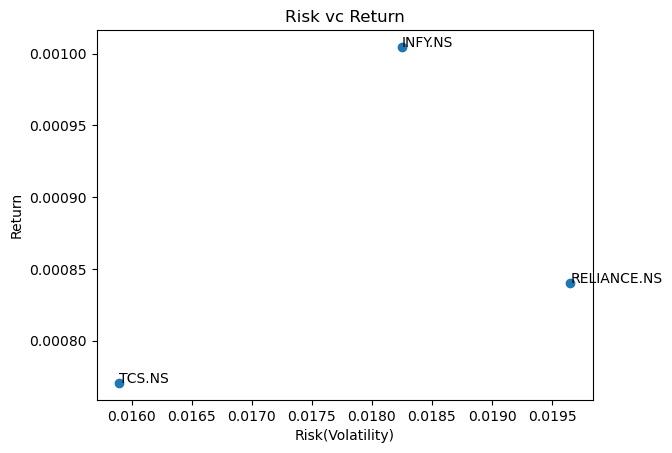

In [81]:
plt.scatter(summary["Risk"], summary["Return"])

for i in summary.index:
    plt.text(summary["Risk"][i], summary["Return"][i], i)

plt.xlabel("Risk(Volatility)")
plt.ylabel("Return")
plt.title("Risk vc Return")
plt.show()

## Step 5: Portfolio Simulation

We generate multiple portfolios with random weights to explore 
different risk-return combinations.

In [82]:
weights = [0.33, 0.33, 0.34]

portfolio_return = (returns.mean() * weights).sum()
portfolio_risk = (returns.cov() @ weights @ weights) ** 0.5

print("Portfolio Return:", portfolio_return)
print("Portfolio Risk:", portfolio_risk)

Portfolio Return: 0.0008708151790576909
Portfolio Risk: 0.014570434605317744


In [83]:
weights = [0.2, 0.2, 0.6]

portfolio_return = (returns.mean() * weights).sum()
portfolio_risk = (returns.cov() @ weights @ weights) ** 0.5

print("Portfolio Return:", portfolio_return)
print("Portfolio Risk:", portfolio_risk)

Portfolio Return: 0.0008313332780869782
Portfolio Risk: 0.014513834953430477


In [84]:
weight2 = [0.2, 0.6, 0.2]
portfolio_return2 = (returns.mean()*weight2).sum()
portfolio_risk2 = (returns.cov() @ weights @ weight2) ** 0.5

print("Portfolio Return:", portfolio_return2)
print("Portfolio Risk:", portfolio_risk2)

Portfolio Return: 0.0008591494841974057
Portfolio Risk: 0.013989159251296705


In [85]:
weight3 = [0.7, 0.2, 0.1]
portfolio_return3 = (returns.mean()*weight3).sum()
portfolio_risk3 = (returns.cov() @ weights @ weight3) ** 0.5

print("Portfolio Return:", portfolio_return3)
print("Portfolio Risk:", portfolio_risk3)

Portfolio Return: 0.0009484164857209157
Portfolio Risk: 0.014510601164094734


In [86]:
weight4 = [0.1, 0.2, 0.7]
portfolio_return4 = (returns.mean()*weight4).sum()
portfolio_risk4 = (returns.cov() @ weights @ weight4) ** 0.5

print("Portfolio Return:", portfolio_return4)
print("Portfolio Risk:", portfolio_risk4)

Portfolio Return: 0.0008079166365601907
Portfolio Risk: 0.014514481624840026


In [87]:
print("Case 1:", portfolio_return2 / portfolio_risk2)
print("Case 2:", portfolio_return3 / portfolio_risk3)
print("Case 3:", portfolio_return4 / portfolio_risk4)

Case 1: 0.06141537663300017
Case 2: 0.06536024765587885
Case 3: 0.05566279647063147


In [88]:
import numpy as np

num_portfolios = 1000

results = []

for _ in range(num_portfolios):
    
    weights = np.random.random(3)
    weights /= np.sum(weights)   # normalize
    
    port_return = (returns.mean() * weights).sum()
    port_risk = (returns.cov() @ weights @ weights) ** 0.5
    
    results.append([port_return, port_risk, weights])

In [89]:
import pandas as pd

df = pd.DataFrame(results, columns=["Return", "Risk", "Weights"])

In [90]:
df

,Return,Risk,Weights
0,0.000827,0.014384,"[0.14962717193855574, 0.30251455681792216, 0.5..."
1,0.000872,0.014879,"[0.2967374767613948, 0.4569317811290054, 0.246..."
2,0.000868,0.014771,"[0.36734853145334495, 0.1609424319828944, 0.47..."
3,0.000846,0.015070,"[0.1624597384124648, 0.5315597163101613, 0.305..."
4,0.000850,0.014460,"[0.2333949223850061, 0.35470302003853266, 0.41..."
...,...,...,...
995,0.000882,0.014704,"[0.40341018714525767, 0.24526151681430508, 0.3..."
996,0.000930,0.015672,"[0.5487172141514491, 0.4400719394050635, 0.011..."
997,0.000882,0.014894,"[0.4263523036852552, 0.1621112478274507, 0.411..."
998,0.000921,0.015265,"[0.5427735506367495, 0.33214883293548847, 0.12..."


### Step 6: Efficient Frontier

We visualize all portfolios and identify the optimal region 
that maximizes return for a given level of risk.

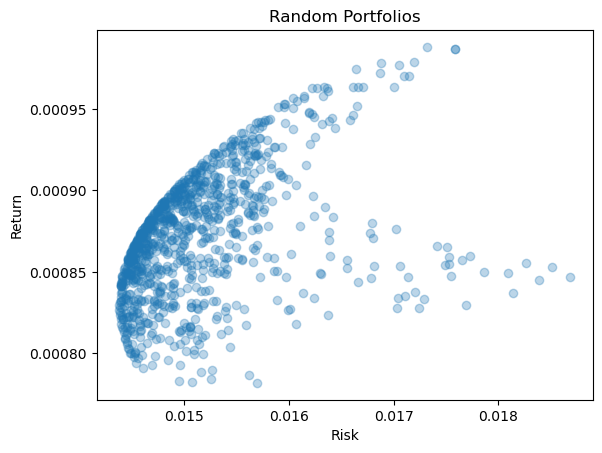

In [91]:
import matplotlib.pyplot as plt

plt.scatter(df["Risk"], df["Return"], alpha=0.3)
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Random Portfolios")
plt.show()

### Step 7: Optimal Portfolio Selection

We select the portfolio with the highest return-to-risk ratio (Sharpe Ratio).
Top left boundary is the BEST portfolio.
This is where magic is:
Higher return, Lower risk


In [93]:
df["Sharpe"] = df["Return"] / df["Risk"]

best = df.loc[df["Sharpe"].idxmax()]

print(best)

Return                                              0.000911
Risk                                                0.015077
Weights    [0.5136788861113487, 0.29158271646874606, 0.19...
Sharpe                                              0.060434
Name: 98, dtype: object


In [94]:
best_return = best["Return"]
best_risk = best["Risk"]
best_weights = best["Weights"]

print("Best Return:", best_return)
print("Best Risk:", best_risk)
print("Best Weights:", best_weights)

Best Return: 0.0009111550476865115
Best Risk: 0.015076909176832869
Best Weights: [0.51367889 0.29158272 0.1947384 ]


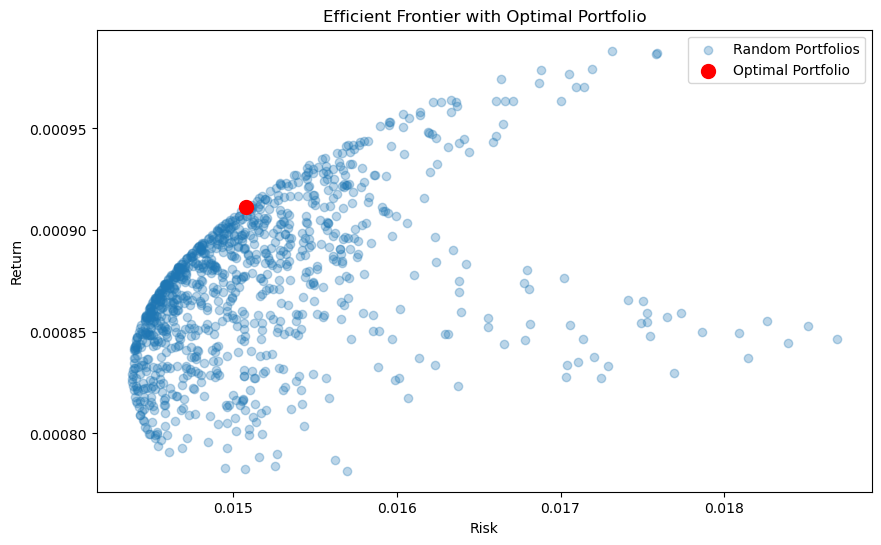

In [95]:
plt.figure(figsize=(10,6))

# Plot all portfolios
plt.scatter(df["Risk"], df["Return"], alpha=0.3, label="Random Portfolios")

# Highlight best portfolio
plt.scatter(best_risk, best_return, color="red", s=100, label="Optimal Portfolio")

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal Portfolio")
plt.legend()

plt.show()

The red point represents the optimal portfolio with the highest 
risk-adjusted return (Sharpe Ratio).

This portfolio provides the best balance between risk and return 
among all simulated portfolios.

#### Now we will find the minimum possible risk portfolio

In [96]:
min_risk_port = df.loc[df["Risk"].idxmin()]

min_risk = min_risk_port["Risk"]
min_return = min_risk_port["Return"]

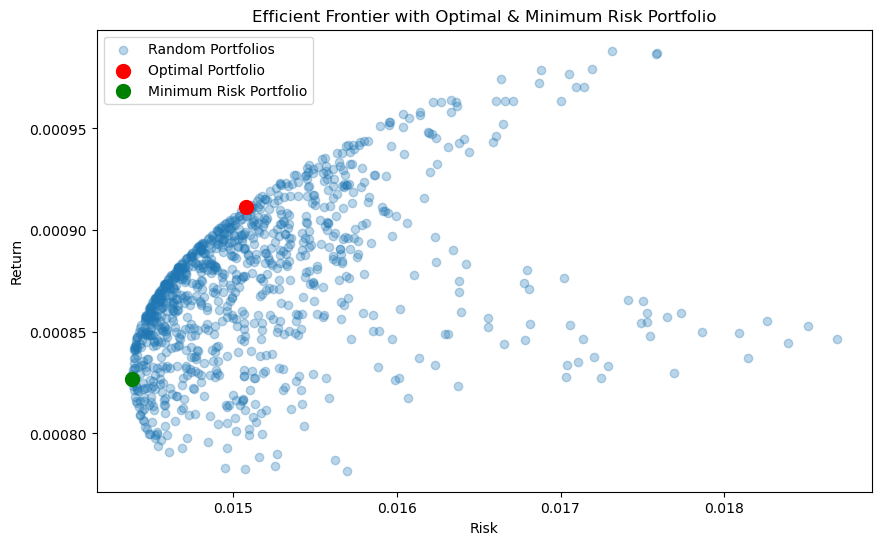

In [97]:
plt.figure(figsize=(10,6))

# All portfolios
plt.scatter(df["Risk"], df["Return"], alpha=0.3, label="Random Portfolios")

# Optimal portfolio (red)
plt.scatter(best_risk, best_return, color="red", s=100, label="Optimal Portfolio")

# Minimum risk portfolio (green)
plt.scatter(min_risk, min_return, color="green", s=100, label="Minimum Risk Portfolio")

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Optimal & Minimum Risk Portfolio")
plt.legend()

plt.show()

#### So here Red dot is the best portfolio while green dot is the safest portfolio

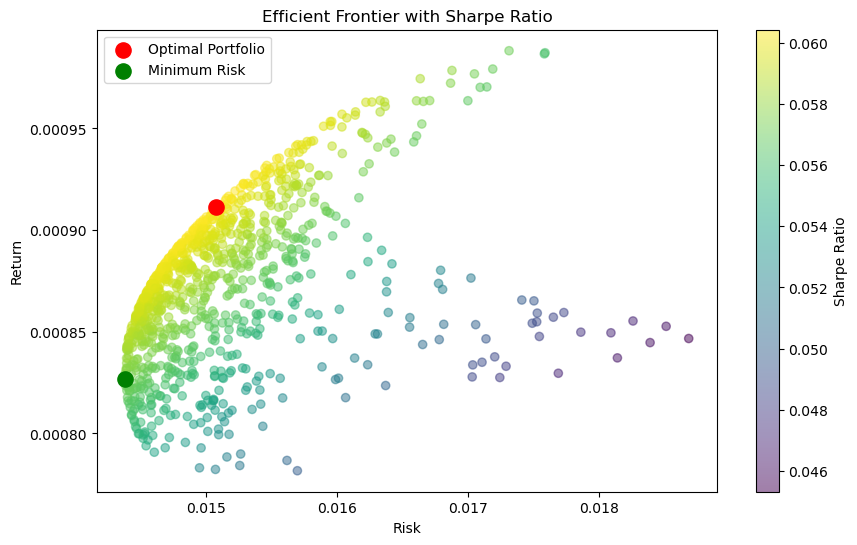

In [98]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    df["Risk"], 
    df["Return"], 
    c=df["Sharpe"], 
    cmap="viridis", 
    alpha=0.5
)

plt.colorbar(scatter, label="Sharpe Ratio")

# Highlight points
plt.scatter(best_risk, best_return, color="red", s=120, label="Optimal Portfolio")
plt.scatter(min_risk, min_return, color="green", s=120, label="Minimum Risk")

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Efficient Frontier with Sharpe Ratio")

plt.legend()
plt.show()

### This visualization shows the Efficient Frontier of randomly generated portfolios.

- The red point represents the portfolio with the highest Sharpe Ratio (optimal).
- The green point represents the portfolio with the lowest risk.
- Color intensity represents risk-adjusted return.

This helps identify the most efficient allocation of assets.